In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ID = '1gi0dfOCPH5z3V-pxJqfVXqw6fA9Vdgr3'

df = pd.read_csv(f'https://drive.google.com/uc?export=download&id={ID}')

df.head()

,year,city,state,city_tier,population_approx,median_salary_gross_usd_monthly,median_salary_net_usd_monthly,median_salary_gross_usd_annual,national_median_gross_usd_monthly,national_median_gross_usd_annual,...,cost_of_living_index,rent_1br_city_center_usd,rent_1br_outside_center_usd,meal_cheap_restaurant_usd,groceries_monthly_usd,public_transport_monthly_usd,est_monthly_cost_single_usd,affordability_ratio,rent_to_income_pct,data_source
0,2010,New York City,New York,megalopolis,8300000,3690,2694,44280,2820,33840,...,95.5,2750,1972,15,424,93,2893,0.93,53.4,numbeo
1,2011,New York City,New York,megalopolis,8300000,3850,2810,46200,2872,34460,...,95.7,2862,1934,15,419,93,2854,0.98,50.2,numbeo
2,2012,New York City,New York,megalopolis,8300000,3893,2842,46716,2896,34750,...,96.0,2692,2045,17,424,98,3017,0.94,52.5,numbeo
3,2013,New York City,New York,megalopolis,8300000,3830,2796,45960,2923,35080,...,97.5,2748,2171,17,463,98,3184,0.88,56.7,numbeo
4,2014,New York City,New York,megalopolis,8300000,4092,2987,49104,2962,35540,...,97.6,2736,2116,16,449,98,3096,0.96,51.7,numbeo


In [ ]:
print("NAN values in sales dataframe:\n", df.isna().sum())
print()
print("Number of Duplicates in the sales dataframe: ", df.duplicated().sum())

NAN values in sales dataframe:
 year                                 0
city                                 0
state                                0
city_tier                            0
population_approx                    0
median_salary_gross_usd_monthly      0
median_salary_net_usd_monthly        0
median_salary_gross_usd_annual       0
national_median_gross_usd_monthly    0
national_median_gross_usd_annual     0
national_mean_gross_usd_monthly      0
fed_min_wage_usd_hourly              0
salary_to_national_ratio             0
cpi_annual_pct                       0
cost_of_living_index                 0
rent_1br_city_center_usd             0
rent_1br_outside_center_usd          0
meal_cheap_restaurant_usd            0
groceries_monthly_usd                0
public_transport_monthly_usd         0
est_monthly_cost_single_usd          0
affordability_ratio                  0
rent_to_income_pct                   0
data_source                          0
dtype: int64

Number of Duplicat

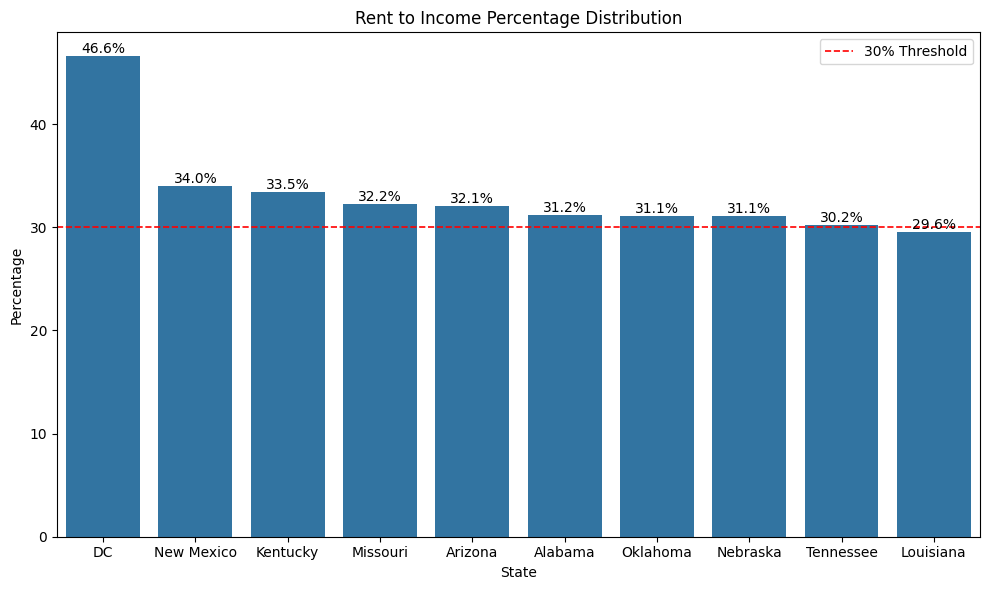

In [102]:
max = df['rent_to_income_pct'].max()
min = df['rent_to_income_pct'].min()

Order = df.groupby('state')['rent_to_income_pct'].mean().sort_values(ascending=False).index[:10]

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df, x="state", y="rent_to_income_pct", order=Order, errorbar=None)
ax.axhline(30, color='r', linestyle='--', linewidth=1.2, label='30% Threshold')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title("Rent to Income Percentage Distribution")
plt.xlabel("State")
plt.ylabel("Percentage")
ax.legend()
plt.tight_layout()
plt.show()

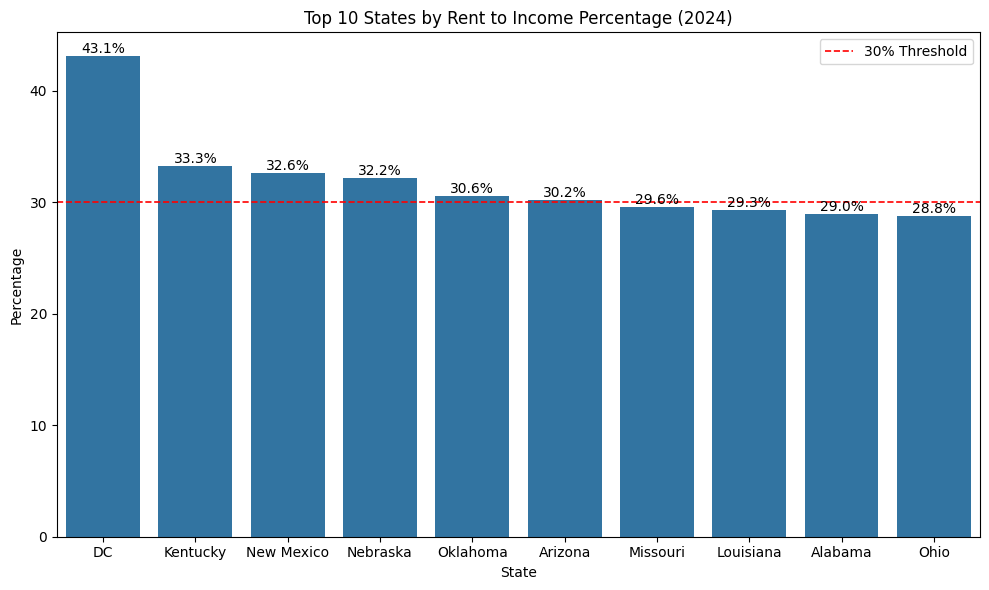

In [ ]:
df2 = df[df['year'] == 2024]
New_Order = df2.groupby('state')['rent_to_income_pct'].mean().sort_values(ascending=False).index[:10]

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df2, x="state", y="rent_to_income_pct", order=New_Order, errorbar=None)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.axhline(30, color='r', linestyle='--', linewidth=1.2, label='30% Threshold')
plt.title("Top 10 States by Rent to Income Percentage (2024)")
plt.xlabel("State")
plt.ylabel("Percentage")
plt.legend()
plt.tight_layout()
plt.show()

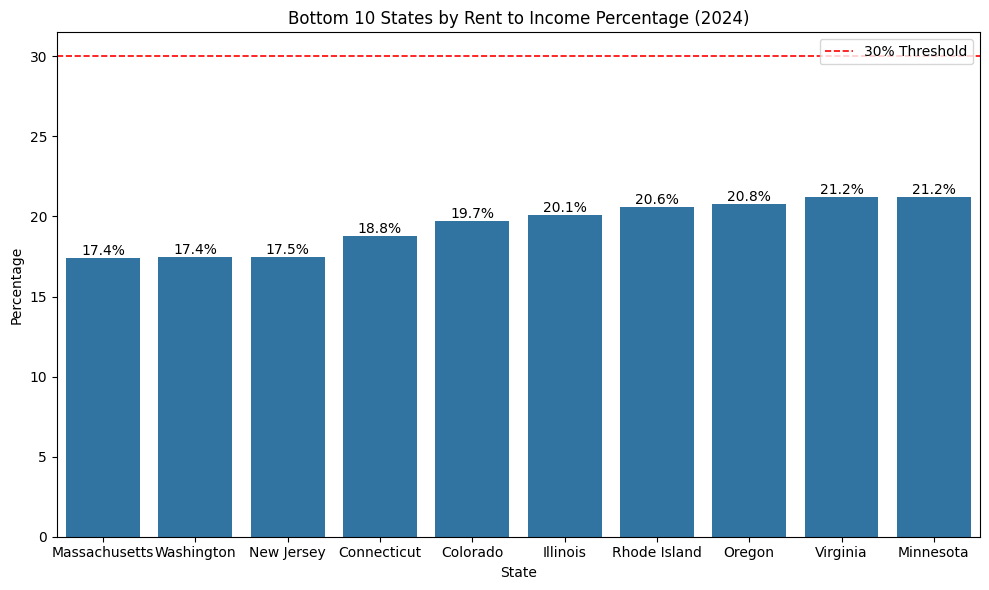

In [ ]:
df3 = df[df['year'] == 2024]
New_Order_2 = df3.groupby('state')['rent_to_income_pct'].mean().sort_values(ascending=True).index[:10]

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df3, x="state", y="rent_to_income_pct", order=New_Order_2, errorbar=None)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.axhline(30, color='r', linestyle='--', linewidth=1.2, label='30% Threshold')
plt.title("Bottom 10 States by Rent to Income Percentage (2024)")
plt.xlabel("State")
plt.ylabel("Percentage")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_14885/715353867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['annual_rent'] = df2['rent_1br_city_center_usd'] * 12


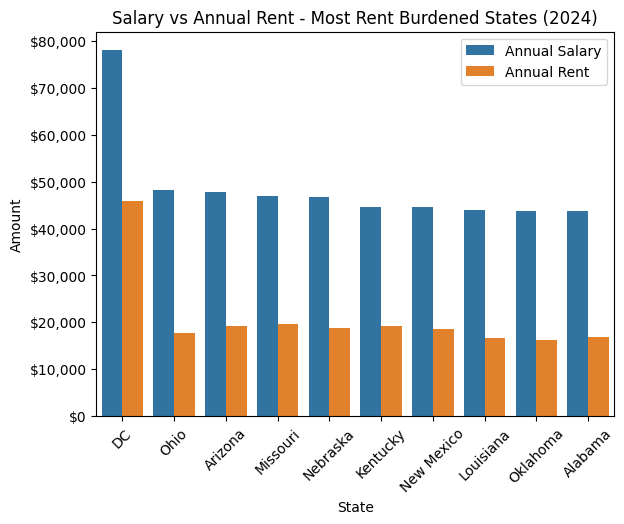

In [ ]:
df2['annual_rent'] = df2['rent_1br_city_center_usd'] * 12
Rent_Salary_group = df2[df2['state'].isin(New_Order)].groupby('state')[['median_salary_gross_usd_annual', 'annual_rent']].mean().sort_values(by= 'median_salary_gross_usd_annual',ascending=False).reset_index()
melted_df = Rent_Salary_group.melt(id_vars='state', value_vars=['median_salary_gross_usd_annual', 'annual_rent'], var_name='metric', value_name='amount')

ax = sns.barplot(data=melted_df, x="state", y="amount", hue="metric", errorbar=None)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Annual Salary', 'Annual Rent'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.title("Salary vs Annual Rent - Most Rent Burdened States (2024)")
plt.xlabel("State")
plt.ylabel("Amount")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_14885/4092013731.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['annual_rent'] = df2['rent_1br_city_center_usd'] * 12


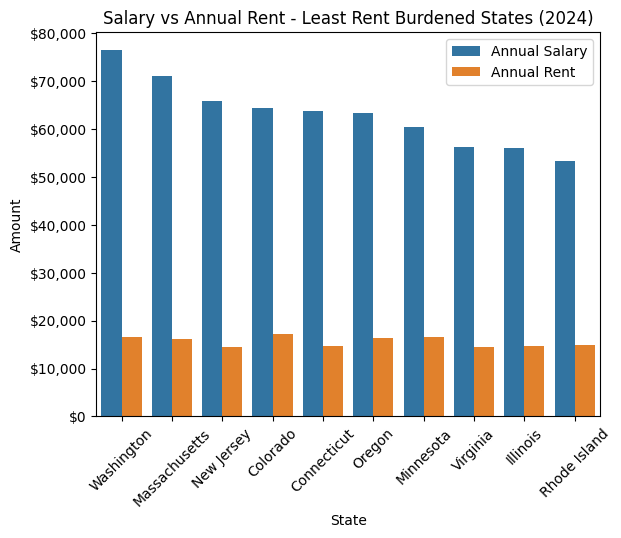

In [ ]:
df2['annual_rent'] = df2['rent_1br_city_center_usd'] * 12
Rent_Salary_group = df2[df2['state'].isin(New_Order_2)].groupby('state')[['median_salary_gross_usd_annual', 'annual_rent']].mean().sort_values(by= 'median_salary_gross_usd_annual',ascending=False).reset_index()
melted_df = Rent_Salary_group.melt(id_vars='state', value_vars=['median_salary_gross_usd_annual', 'annual_rent'], var_name='metric', value_name='amount')

ax = sns.barplot(data=melted_df, x="state", y="amount", hue="metric", errorbar=None)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Annual Salary', 'Annual Rent'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.title("Salary vs Annual Rent - Least Rent Burdened States (2024)")
plt.xlabel("State")
plt.ylabel("Amount")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

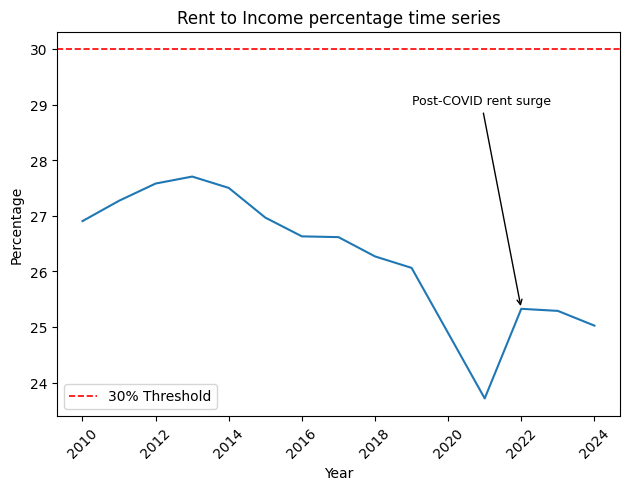

In [84]:
group = df.groupby('year')['rent_to_income_pct'].mean().reset_index()

ax = sns.lineplot(data=group, x="year", y="rent_to_income_pct", errorbar=None)

plt.title("Rent to Income percentage time series")
ax.axhline(30, color='r', linestyle='--', linewidth=1.2, label='30% Threshold')
ax.annotate('Post-COVID rent surge',
            xy=(2022, group.loc[group['year']==2022, 'rent_to_income_pct'].values[0]),
            xytext=(2019, 29),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9)
ax.legend()
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

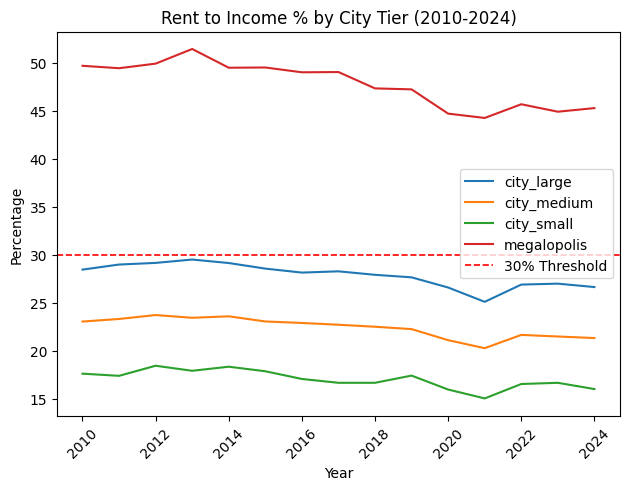

In [98]:
group_2 = df.groupby(['year', 'city_tier'])['rent_to_income_pct'].mean().reset_index()

ax = sns.lineplot(data=group_2, x="year", y="rent_to_income_pct", hue="city_tier", errorbar=None)

plt.title("Rent to Income % by City Tier (2010-2024)")
ax.axhline(30, color='r', linestyle='--', linewidth=1.2, label='30% Threshold')
ax.legend()
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()